# 单头自注意力模块

Attention 机制最关键的地方, 在大多数教程里被解释为 `Q` 是查询, `K` 是键, `V` 是值, 这个说法作为辅助理解的记号无可厚非, 但并没有触及底层.

更本质地说, `Q`, `K` 和 `V` 在结构上其实没什么区别. 它们都只是从相同的输入 `X` 经过不同矩阵变换得到的特征矩阵:

$$Q=XW_Q,\quad K=XW_K,\quad V=XW_V$$

事实上, 即使你将 `Q/K` 在公式中调换位置, 其表达能力理论上也是不变的. 

所以真正重要的不是 `Q/K` 这个名字, 而是:

$$QK^T$$

这个**矩阵乘法**操作.

我们知道对两个向量做点积操作可以理解为是计算彼此之间的相似性, 关系强度或者耦合程度, 对矩阵而言则是批量给很多个向量做点积运算. 算完之后得到的注意力分数, 本质上就是一个任意 token 到 token 的关系矩阵. 

由于神经网络参数太复杂, 所以一般将 `Q/K` 近似建模为独立同分布随机变量, 而由于独立随机变量点积的数值波动尺度即标准差随向量维度的平方根增长, 这样会导致高维矩阵的数值尺度膨胀. 所以我们要除以 $\sqrt{d_k}$ 以抵消维度带来的尺度影响, 这更多是出于工程上训练稳定性的考量:

$$\frac{QK^T}{\sqrt{d_k}}$$

然后 softmax 对这个关系矩阵的最后一维, 也就是每一行做归一化, 每一行的所有元素之和为 1. 于是, 第 `i` 行的每个元素自然就可以理解为从所有 `token` 信息汇聚的比例.

$$A = softmax(\frac{QK^T}{\sqrt{d_k}})$$

这也就是为什么 `Q/K` 分经常被称为查询/键了: `A` 的第 `i` 行是 `Q` 的第 `i` 个 token 分别与 `K` 中每个 token 做点积并归一化得到的权重, 代表该 token 从每个 token 汇聚信息的比例.

最后再乘上矩阵 `V`:

$$softmax(\frac{QK^T}{\sqrt{d_k}})V$$

本质上是以 `A` 的每一行作为权重, 对 `V` 所有行做加权求和. 第 `i` 个 token 的输出表示向量就是 `V` 中所有 token 的信息按比例混合后的结果.

也就是说, Attention 的根本贡献是构建了一个理论上限更高的可学习结构: 它不再像 `CNN/RNN` 那样依赖固定的局部结构或顺序结构(卷积核强制局部性, RNN 强制时序), 而是将关系视为一等公民, 设计了可让模型自己学习**谁应该和谁有关系**的模型.

根据上述解释, 完整公式即为:

$$Attention(Q,K,V)=softmax(\frac{QK^T}{\sqrt{d_k}})V$$

下面是实现最小可用版本的自注意力的具体步骤:

1. 首先输入要求为一个序列`x`, 这里为了方便处理默认输入一个离散的数字序列, 序列中每个数字就是一个token.

2. 经过`nn.Embedding`将每个token映射到维度为`d_model`的空间中, 得到`x: (batch, seq_len, d_model)`.

3. 然后同一个输入x分别线性映射成`Q/K/V`.

4. `Q @ K.transpose(-2, -1)`这一段代码是计算每个位置的查询Q和所有位置的键K之间的相关性分数, 为避免计算出的结果太大, 所以后面要缩放, 除以`self.d_model ** 0.5`, 然后对最后一维进行`softmax`得到注意力权重`attn_w: (batch, seq_len, seq_len)`
   >  经典线性代数教材是列向量优先时$S=KQ$, 但这里是行向量优先, 行向量优先时$S=QK^T$, 两者在数学上完全等价

5. 用注意力权重对 `V` 加权求和得到`output: (batch, seq_len, d_model)`, 再经过输出层得到最终 logits.



In [ ]:
import torch
from torch import nn
from sklearn.metrics import classification_report

class SelfAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model):
        super().__init__()
        # d_model: token 的隐藏维度
        # output_dim: 每个位置输出的类别数（例如实验1是1路位置分类，实验2是2路位置分类）
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None  # 缓存最近一次的注意力权重用于可视化
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        # (batch, seq_len) -> (batch, seq_len, d_model)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_model ** 0.5 # @等价于torch.matmul函数 为方便使用@
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()  # 缓存
        output = attn_w @ V          # (batch, seq_len, d_model)
        return self.out(output)      # (batch, seq_len, output_dim)



## 注意力热力图可视化函数

该函数会绘制 batch 前 4 个样本的注意力矩阵, 帮助观察:

- 每个 query 位置更关注哪些 key 位置

- 注意力是否集中到任务相关位置

In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Batch", cmap="Blues"):
    attn_w = attn_w[:4].detach().cpu().float()

    seq_len = attn_w.shape[1]
    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)

        labels = tokens[n]
        ax.set_xticks(range(seq_len))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(seq_len))
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_title(f"{title} [{n}]", fontsize=9)

        for i in range(seq_len):
            for j in range(seq_len):
                val = attn_w[n, i, j].item()
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if val > 0.6 else "black")

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()


# 实验1 找最大值下标

## 1. 数据集构建
我们选一个任务来把这个最简单的自注意力用起来, 从一堆乱序数字中找出最大值的下标

数据集构建: 
- 数据: 一堆乱序的数字 [[3, 2, 1, 5, 7],
                [1, 6, 2, 6, 1]]
- 标签: [4, 1]

实验目标: 我们把它定义为分类问题, 即输出最大的数字下标

为了测试这个模块的效果, 我们来构造一个数据集

In [3]:
def get_batch(batch, sql_len, low, high):
    # x: 随机整数序列，y: 最大值所在下标
    x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    y = torch.argmax(x, dim=-1)  # (batch_size,)
    return x, y
print(get_batch(2, 5, 0, 10))


(tensor([[7, 8, 6, 5, 3],
        [3, 9, 4, 4, 4]]), tensor([1, 1]))


## 2. 模型训练
输出层设置为 `output_dim=1`, 表示每个位置只输出1个logit.

模型输出形状是 `(batch, seq_len, 1)`, 压缩后变成 `(batch, seq_len)`.

用 `CrossEntropyLoss` 把 `seq_len` 视为类别数, 即预测哪个位置是最大值.

超参数设置为:
| vocab_size | d_model | lr | train_steps |
|-|-|-|-|
| 100 | 32 | 0.01 | 100 |

In [4]:

train_steps = 100

model = SelfAttention(vocab_size=100, output_dim=1, d_model=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(train_steps):
    train_x, train_y = get_batch(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x).squeeze(-1)  # (batch, seq_len, 1) -> (batch, seq_len)
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(f"Step {i+1}, Loss: {loss.item():.4f}")


Step 10, Loss: 1.4200
Step 20, Loss: 0.5450
Step 30, Loss: 0.3162
Step 40, Loss: 0.1957
Step 50, Loss: 0.1587
Step 60, Loss: 0.1277
Step 70, Loss: 0.0934
Step 80, Loss: 0.0747
Step 90, Loss: 0.0819
Step 100, Loss: 0.0785


## 3. 评估结果

查看预测下标与真实下标, 并结合注意力图理解模型行为.

              precision    recall  f1-score   support

           0     0.9911    1.0000    0.9955       111
           1     0.9898    0.9700    0.9798       100
           2     0.9915    0.9832    0.9873       119
           3     0.9808    0.9808    0.9808       104
           4     1.0000    0.9802    0.9900       101
           5     0.9417    0.9898    0.9652        98
           6     0.9725    0.9907    0.9815       107
           7     0.9706    0.9706    0.9706        68
           8     0.9825    0.9573    0.9697       117
           9     1.0000    1.0000    1.0000        99

    accuracy                         0.9824      1024
   macro avg     0.9820    0.9822    0.9820      1024
weighted avg     0.9827    0.9824    0.9824      1024

------------------------------
input : [91, 2, 65, 36, 86, 82, 87, 3, 71, 68]
pred  : 0
target: 0
------------------------------
input : [3, 84, 75, 99, 48, 13, 3, 49, 60, 8]
pred  : 3
target: 3
------------------------------
input : [10, 33

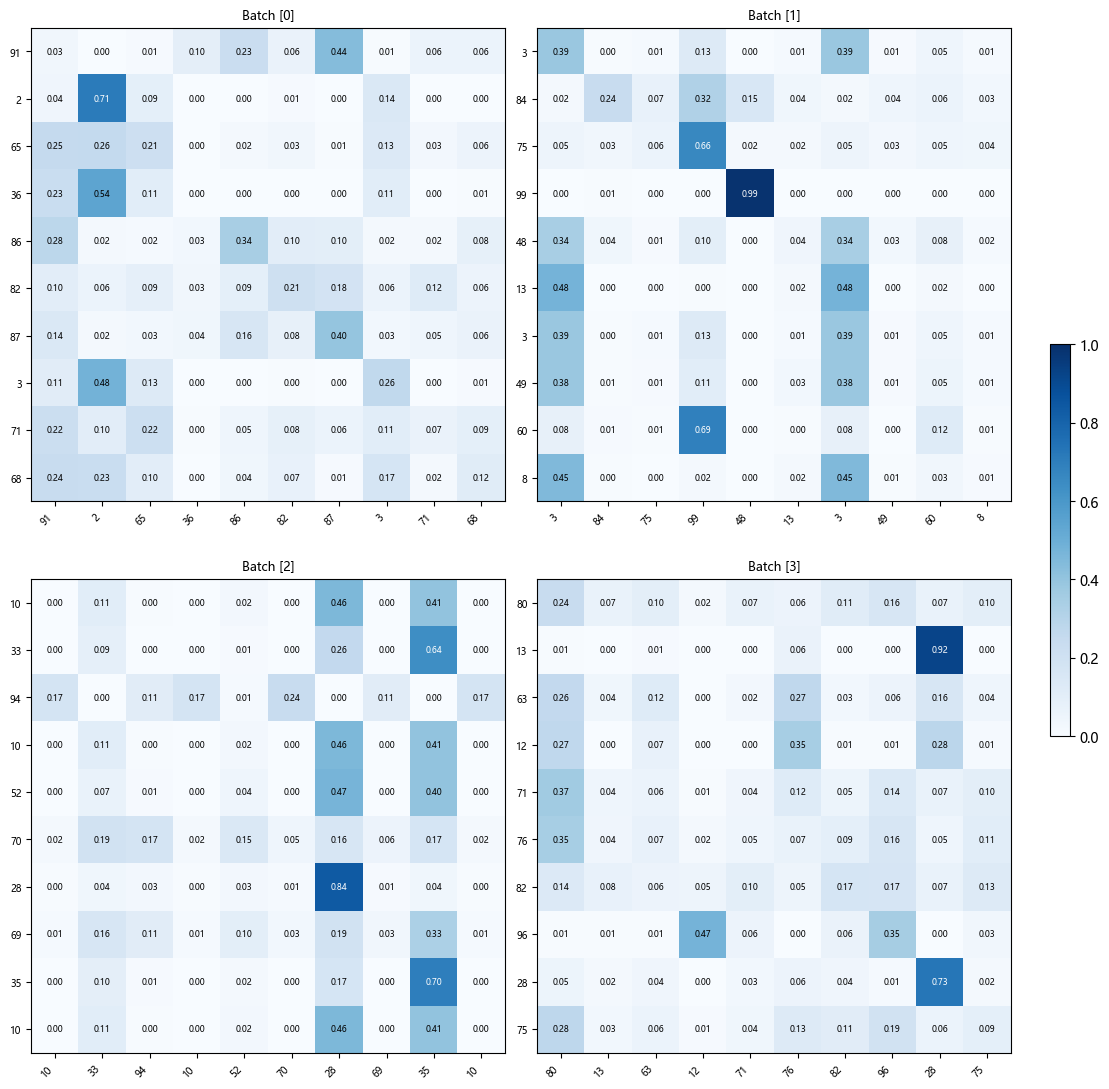

In [5]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_batch(1024, 10, 1, 100)
    eval_logits = model(eval_x).squeeze(-1)          # (1024, seq_len)
    eval_pred = eval_logits.argmax(dim=-1)           # (1024,)

    print(
        classification_report(
            eval_y.cpu().numpy(),
            eval_pred.cpu().numpy(),
            digits=4,
            zero_division=0
        )
    )

    test_x, test_y = get_batch(4, 10, 1, 100)

    logits = model(test_x).squeeze(-1) # (batch, seq_len, 1) -> (batch, seq_len)
    pred = torch.argmax(logits, dim=-1)  # logits转换成softmax概率 (batch, seq_len)

    for i in range(test_x.size(0)):
        print("-" * 30)
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].tolist()}")
        print(f"target: {test_y[i].tolist()}")
    
    sample_tokens = [[str(v) for v in row] for row in test_x.tolist()]
    plot_attention(model.attn_w, tokens=sample_tokens)


# 实验2 同时找最大值和最小值下标

## 1. 数据集构建

与实验1相比, 这里同一输入需要同时完成两个目标:

- 预测最大值位置

- 预测最小值位置


In [6]:
def get_batch_max_min(batch, sql_len, low, high):
    # y[:, 0] 是 max 下标，y[:, 1] 是 min 下标
    train_x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    max_y = torch.argmax(train_x, dim=-1)  # (batch_size,)
    min_y = torch.argmin(train_x, dim=-1)  # (batch_size,)
    return train_x, torch.stack([max_y, min_y], dim=-1)  # (batch_size, 2)
get_batch_max_min(2, 5, 0, 10)

(tensor([[9, 2, 2, 6, 0],
         [2, 7, 7, 0, 9]]),
 tensor([[0, 4],
         [4, 3]]))

## 2. 训练实验

因此输出层设为 `output_dim=2`, 分别对应 max/min 两路预测.

`pred` 形状是 `(batch, seq_len, 2)`: 

- `pred[:, :, 0]` 用来做最大值位置分类

- `pred[:, :, 1]` 用来做最小值位置分类

总损失为两路交叉熵之和.

超参数设置为:
| vocab_size | d_model | lr | train_steps |
|-|-|-|-|
| 100 | 32 | 0.01 | 100 |

In [7]:
train_steps = 100
model = SelfAttention(vocab_size=100, output_dim=2, d_model=32)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(train_steps):
    train_x, train_y = get_batch_max_min(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x)  # (batch, seq_len, 2)

    pred_max = pred[:, :, 0]  # (batch, seq_len)
    pred_min = pred[:, :, 1]  # (batch, seq_len)
    loss_max = criterion(pred_max, train_y[:, 0])
    loss_min = criterion(pred_min, train_y[:, 1])
    loss = loss_max + loss_min

    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(
            f"Step {i+1}, Loss: {loss.item():.4f}, "
            f"MaxLoss: {loss_max.item():.4f}, MinLoss: {loss_min.item():.4f}"
        )

Step 10, Loss: 3.3869, MaxLoss: 1.5165, MinLoss: 1.8704
Step 20, Loss: 1.8708, MaxLoss: 0.7962, MinLoss: 1.0746
Step 30, Loss: 1.2087, MaxLoss: 0.5833, MinLoss: 0.6254
Step 40, Loss: 0.6891, MaxLoss: 0.3151, MinLoss: 0.3741
Step 50, Loss: 0.5123, MaxLoss: 0.2532, MinLoss: 0.2591
Step 60, Loss: 0.4250, MaxLoss: 0.2009, MinLoss: 0.2240
Step 70, Loss: 0.3092, MaxLoss: 0.1350, MinLoss: 0.1742
Step 80, Loss: 0.2914, MaxLoss: 0.1601, MinLoss: 0.1313
Step 90, Loss: 0.2379, MaxLoss: 0.1210, MinLoss: 0.1169
Step 100, Loss: 0.2484, MaxLoss: 0.1203, MinLoss: 0.1282


## 3. 评估实验

同时打印 max/min 两路预测结果, 并观察注意力图是否出现对极值位置的关注模式

MAX task
              precision    recall  f1-score   support

           0     0.9794    1.0000    0.9896        95
           1     1.0000    0.9820    0.9909       111
           2     0.9820    0.9820    0.9820       111
           3     0.9468    0.9780    0.9622        91
           4     1.0000    0.9820    0.9909       111
           5     0.9903    0.9623    0.9761       106
           6     0.9528    0.9712    0.9619       104
           7     1.0000    0.9811    0.9905       106
           8     0.9898    1.0000    0.9949        97
           9     0.9785    0.9891    0.9838        92

    accuracy                         0.9824      1024
   macro avg     0.9820    0.9828    0.9823      1024
weighted avg     0.9827    0.9824    0.9825      1024

MIN task
              precision    recall  f1-score   support

           0     0.9429    0.9706    0.9565       102
           1     0.9804    0.9804    0.9804       102
           2     0.9785    0.9785    0.9785        93
      

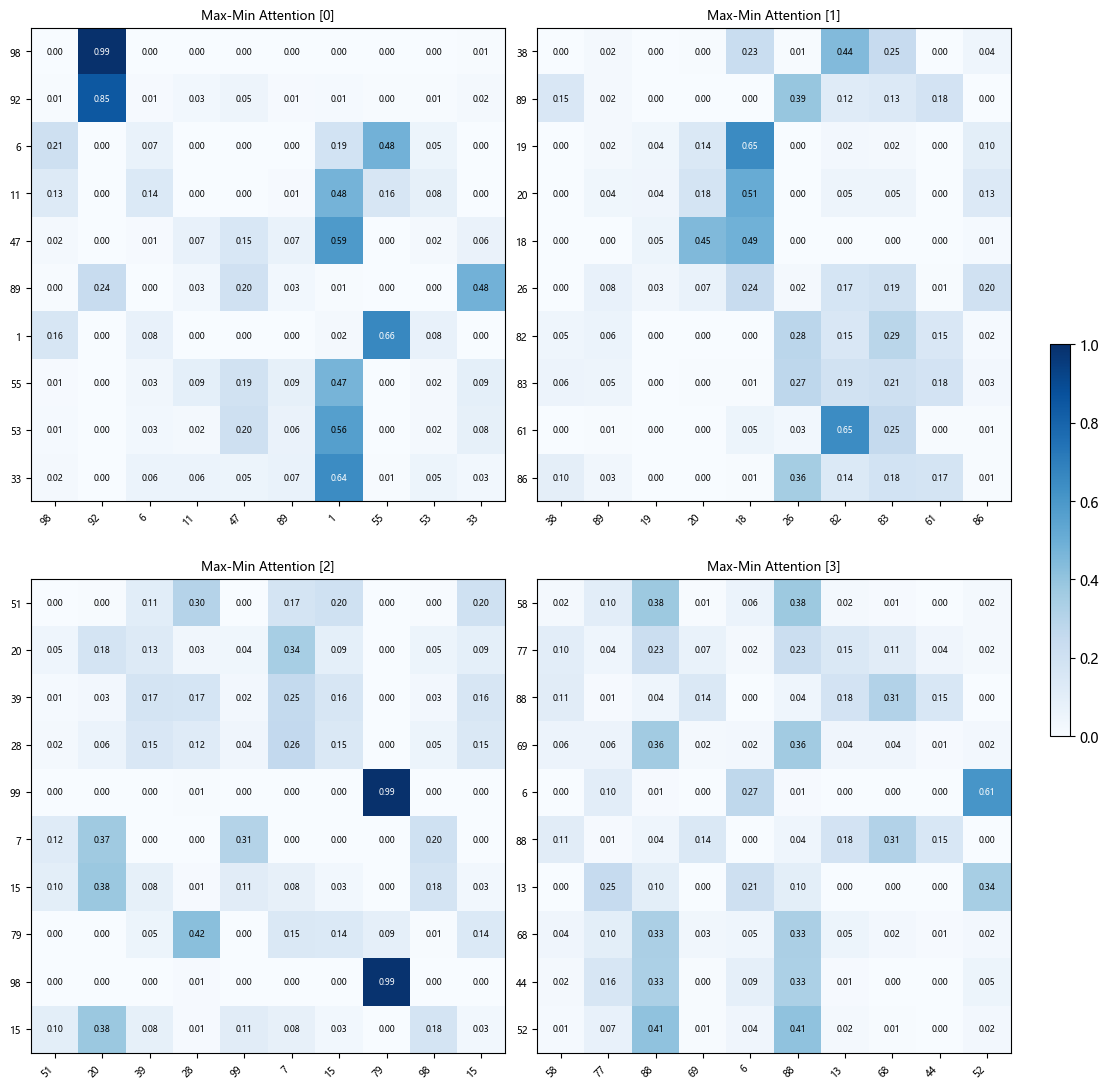

In [8]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_batch_max_min(1024, 10, 1, 100)
    eval_pred = model(eval_x)  # (batch, seq_len, 2)

    eval_pred_max = eval_pred[:, :, 0].argmax(dim=-1).cpu().numpy()
    eval_pred_min = eval_pred[:, :, 1].argmax(dim=-1).cpu().numpy()
    eval_y_max = eval_y[:, 0].cpu().numpy()
    eval_y_min = eval_y[:, 1].cpu().numpy()

    print("MAX task")
    print(classification_report(eval_y_max, eval_pred_max, digits=4, zero_division=0))

    print("MIN task")
    print(classification_report(eval_y_min, eval_pred_min, digits=4, zero_division=0))

    test_x, test_y = get_batch_max_min(4, 10, 1, 100)
    
    pred = model(test_x)
    pred_max = pred[:, :, 0].argmax(dim=-1)
    pred_min = pred[:, :, 1].argmax(dim=-1)

    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : [max={pred_max[i].item()}, min={pred_min[i].item()}]")
        print(f"target: [max={test_y[i,0].item()}, min={test_y[i,1].item()}]")
        print("-" * 30)
    
    sample_tokens = [[str(v) for v in row] for row in test_x.tolist()]
    plot_attention(model.attn_w, tokens=sample_tokens, title="Max-Min Attention")

